# Pareto Design Dashboard

## What you will learn
How final design decisions expose tradeoffs rather than producing one universally best stellarator.

## Codes used
Pure Python cached metrics table.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`11_pareto_front.png` and `11_weighted_selection.png`.

## What this teaches

The object is the decision surface: multiple designs that trade transport, coils, profiles, and risk.

## What this does not prove

It does not prove a single best stellarator or replace expert value judgments.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.pareto import design_table, nondominated, weighted_selection
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
df = design_table()
df

,design,qs_residual,epsilon_eff,coil_length,curvature,normal_field_error,turbulence_proxy,profile_error
0,HSX-thread,0.025,0.018,1.15,1.20,0.24,0.36,0.25
1,W7X-ref,0.040,0.013,1.30,1.32,0.18,0.28,0.22
2,QA-coils,0.020,0.021,1.42,1.46,0.16,0.42,0.32
3,QI-transport,0.032,0.011,1.55,1.60,0.22,0.30,0.24
4,easy-coils,0.060,0.036,0.92,0.98,0.44,0.50,0.40
5,balanced,0.030,0.017,1.12,1.18,0.20,0.26,0.20
6,aggressive-QS,0.014,0.015,1.68,1.75,0.12,0.47,0.36
7,profile-safe,0.038,0.016,1.20,1.25,0.25,0.24,0.18


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

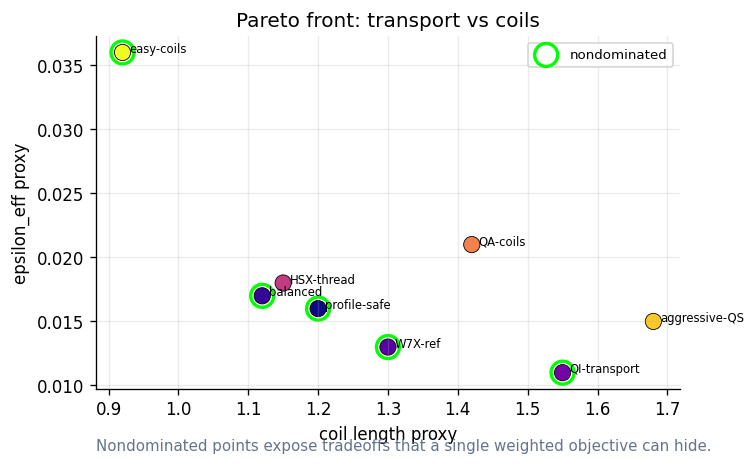

In [7]:
keep = nondominated(df, ["epsilon_eff", "coil_length", "turbulence_proxy"])
fig, ax = plt.subplots(figsize=(6.4, 4.0))
sc = ax.scatter(df["coil_length"], df["epsilon_eff"], c=df["turbulence_proxy"], s=95, cmap="plasma", edgecolor="black", linewidth=0.5)
ax.scatter(df.loc[keep, "coil_length"], df.loc[keep, "epsilon_eff"], facecolors="none", edgecolors="lime", s=190, linewidths=2, label="nondominated")
for _, row in df.iterrows():
    ax.text(row["coil_length"] + 0.01, row["epsilon_eff"], row["design"], fontsize=7)
ax.set_xlabel("coil length proxy")
ax.set_ylabel("epsilon_eff proxy")
ax.set_title("Pareto front: transport vs coils")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "Nondominated points expose tradeoffs that a single weighted objective can hide.")
savefig(fig, "11_pareto_front.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

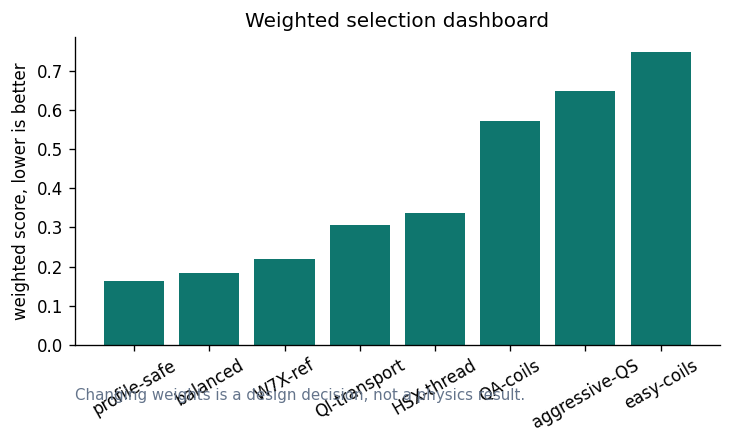

,design,weighted_score
7,profile-safe,0.162105
5,balanced,0.182657
1,W7X-ref,0.218734
3,QI-transport,0.305838
0,HSX-thread,0.336770


In [8]:
weights = {"epsilon_eff": 0.35, "coil_length": 0.25, "turbulence_proxy": 0.25, "profile_error": 0.15}
ranked = weighted_selection(df, weights)
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(ranked["design"], ranked["weighted_score"], color="#0f766e")
ax.set_ylabel("weighted score, lower is better")
ax.set_title("Weighted selection dashboard")
ax.tick_params(axis="x", rotation=30)
caption(ax, "Changing weights is a design decision, not a physics result.")
savefig(fig, "11_weighted_selection.png")
plt.show()
ranked[["design", "weighted_score"]].head()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
value_choices = pd.DataFrame({
    "decision": ["transport priority", "coil simplicity", "validation maturity", "profile confidence"],
    "effect": ["favors low epsilon/turbulence", "favors shorter/smoother coils", "penalizes unvalidated proxies", "favors profile-safe points"],
})
value_choices

,decision,effect
0,transport priority,favors low epsilon/turbulence
1,coil simplicity,favors shorter/smoother coils
2,validation maturity,penalizes unvalidated proxies
3,profile confidence,favors profile-safe points


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    print("Research path: replace any cached metric column with a real output and recompute the front.")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,priority,selected_design,score
0,transport-first,W7X-ref,0.158596
1,coil-first,balanced,0.256527
2,balanced,balanced,0.207520


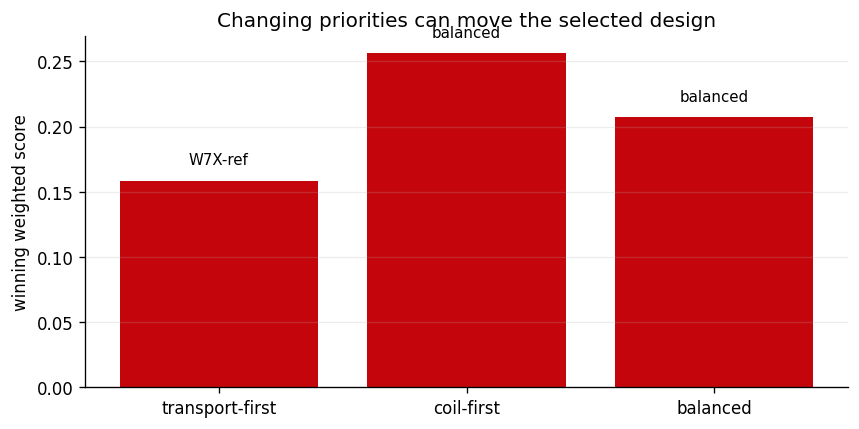

Caption: the Pareto dashboard is a decision tool; the selected design should move when the program priorities move.


In [13]:
from sos2026.pareto import design_table, weighted_selection
df = design_table()
weight_sets = {
    "transport-first": {"epsilon_eff": 0.45, "turbulence_proxy": 0.35, "coil_length": 0.10, "normal_field_error": 0.10},
    "coil-first": {"coil_length": 0.35, "curvature": 0.30, "normal_field_error": 0.25, "epsilon_eff": 0.10},
    "balanced": {"epsilon_eff": 0.25, "turbulence_proxy": 0.25, "coil_length": 0.25, "normal_field_error": 0.25},
}
rows = []
for label, weights in weight_sets.items():
    selected = weighted_selection(df, weights).iloc[0]
    rows.append({"priority": label, "selected_design": selected["design"], "score": selected["weighted_score"]})
choice_table = pd.DataFrame(rows)
display(choice_table)
fig, ax = plt.subplots(figsize=(8.2, 3.8))
ax.bar(choice_table["priority"], choice_table["score"], color="#c5050c")
for i, row in choice_table.iterrows():
    ax.text(i, row["score"] + 0.01, row["selected_design"], ha="center", va="bottom", fontsize=9)
ax.set_ylabel("winning weighted score")
ax.set_title("Changing priorities can move the selected design")
ax.grid(axis="y", alpha=0.22)
plt.show()
print("Caption: the Pareto dashboard is a decision tool; the selected design should move when the program priorities move.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.